In [1]:
# Cell 1 — Import all libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import requests
import json
import os
import zipfile
import io
from datetime import datetime

print("✅ All libraries loaded!")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

✅ All libraries loaded!
Pandas: 2.3.3
Numpy: 2.3.5


In [2]:
# Cell 2 — Download real IPL match data from Cricsheet (free, no API key!)
print("📥 Downloading IPL data... this may take 30-60 seconds")

url = "https://cricsheet.org/downloads/ipl_csv2.zip"
response = requests.get(url, timeout=60)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("ipl_data")

files = os.listdir("ipl_data")
csv_files = [f for f in files if f.endswith('.csv')]

print(f"✅ Download complete!")
print(f"📊 Total match files: {len(csv_files)}")
print(f"🗂️ Sample files: {csv_files[:3]}")

📥 Downloading IPL data... this may take 30-60 seconds
✅ Download complete!
📊 Total match files: 2386
🗂️ Sample files: ['598068.csv', '1304076.csv', '598040.csv']


In [3]:
# Cell 3 — Load & explore the data
import glob

# Load all CSV files
all_files = glob.glob("ipl_data/*.csv")

# Read and combine all match data
df_list = []
for f in all_files[:500]:  # Load first 500 files to keep it fast
    try:
        temp = pd.read_csv(f)
        df_list.append(temp)
    except:
        pass

df = pd.concat(df_list, ignore_index=True)

print(f"✅ Total rows loaded: {len(df)}")
print(f"📋 Total columns: {len(df.columns)}")
print(f"\n📊 Column names:")
for col in df.columns:
    print(f"  → {col}")

print(f"\n🔍 First 3 rows:")
df.head(3)

✅ Total rows loaded: 55912
📋 Total columns: 22

📊 Column names:
  → match_id
  → season
  → start_date
  → venue
  → innings
  → ball
  → batting_team
  → bowling_team
  → striker
  → non_striker
  → bowler
  → runs_off_bat
  → extras
  → wides
  → noballs
  → byes
  → legbyes
  → penalty
  → wicket_type
  → player_dismissed
  → other_wicket_type
  → other_player_dismissed

🔍 First 3 rows:


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,598068,2013,2013-05-18,M Chinnaswamy Stadium,1,0.1,Royal Challengers Bangalore,Chennai Super Kings,V Kohli,CH Gayle,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,598068,2013,2013-05-18,M Chinnaswamy Stadium,1,0.2,Royal Challengers Bangalore,Chennai Super Kings,V Kohli,CH Gayle,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,598068,2013,2013-05-18,M Chinnaswamy Stadium,1,0.3,Royal Challengers Bangalore,Chennai Super Kings,V Kohli,CH Gayle,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Cell 4 — Clean & understand the data (fixed)
# Fix season column type
df['season'] = df['season'].astype(str)

print("🏏 IPL Seasons in our data:")
print(sorted(df['season'].unique(), key=str))

print(f"\n🏟️ Total unique venues: {df['venue'].nunique()}")
print(f"👥 Total unique teams: {df['batting_team'].nunique()}")
print(f"🧑 Total unique players (batters): {df['striker'].nunique()}")
print(f"🎳 Total unique bowlers: {df['bowler'].nunique()}")

print(f"\n🏆 Teams in the data:")
for team in sorted(df['batting_team'].unique()):
    print(f"  → {team}")

🏏 IPL Seasons in our data:
['2007/08', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2019', '2020/21', '2021', '2022', '2024', '2025']

🏟️ Total unique venues: 41
👥 Total unique teams: 19
🧑 Total unique players (batters): 493
🎳 Total unique bowlers: 394

🏆 Teams in the data:
  → Chennai Super Kings
  → Deccan Chargers
  → Delhi Capitals
  → Delhi Daredevils
  → Gujarat Lions
  → Gujarat Titans
  → Kings XI Punjab
  → Kochi Tuskers Kerala
  → Kolkata Knight Riders
  → Lucknow Super Giants
  → Mumbai Indians
  → Pune Warriors
  → Punjab Kings
  → Rajasthan Royals
  → Rising Pune Supergiant
  → Rising Pune Supergiants
  → Royal Challengers Bangalore
  → Royal Challengers Bengaluru
  → Sunrisers Hyderabad


In [5]:
# Cell 5 — Build Team Stats
print("⚙️ Building team statistics...")

# Total runs per team per season
team_runs = df.groupby(['season', 'batting_team']).agg(
    total_runs = ('runs_off_bat', 'sum'),
    total_balls = ('ball', 'count'),
    total_wickets = ('player_dismissed', 'count')
).reset_index()

# Run rate
team_runs['run_rate'] = (team_runs['total_runs'] / team_runs['total_balls'] * 6).round(2)

print("✅ Team stats ready!")
print(f"📊 Shape: {team_runs.shape}")
team_runs.head(20)

⚙️ Building team statistics...
✅ Team stats ready!
📊 Shape: (123, 6)


,season,batting_team,total_runs,total_balls,total_wickets,run_rate
0,2007/08,Chennai Super Kings,698,478,16,8.76
1,2007/08,Deccan Chargers,308,244,15,7.57
2,2007/08,Delhi Daredevils,269,222,9,7.27
3,2007/08,Kings XI Punjab,686,493,28,8.35
4,2007/08,Kolkata Knight Riders,552,497,25,6.66
5,2007/08,Mumbai Indians,386,367,19,6.31
6,2007/08,Rajasthan Royals,773,594,29,7.81
7,2007/08,Royal Challengers Bangalore,511,472,33,6.50
8,2009/10,Chennai Super Kings,468,370,16,7.59
9,2009/10,Deccan Chargers,316,353,27,5.37


In [6]:
# Cell 6 — Top Run Scorers (All Time)
top_batters = df.groupby('striker').agg(
    total_runs = ('runs_off_bat', 'sum'),
    total_balls = ('ball', 'count'),
    dismissals = ('player_dismissed', 'count')
).reset_index()

# Strike rate
top_batters['strike_rate'] = (top_batters['total_runs'] / top_batters['total_balls'] * 100).round(2)

# Sort by runs
top_batters = top_batters.sort_values('total_runs', ascending=False).reset_index(drop=True)

print("✅ Top batters ready!")
print("\n🏏 Top 10 Run Scorers in our dataset:")
top_batters[['striker', 'total_runs', 'total_balls', 'strike_rate']].head(10)

✅ Top batters ready!

🏏 Top 10 Run Scorers in our dataset:


,striker,total_runs,total_balls,strike_rate
0,V Kohli,1790,1399,127.95
1,KL Rahul,1361,988,137.75
2,RG Sharma,1309,1038,126.11
3,S Dhawan,1187,948,125.21
4,F du Plessis,1176,938,125.37
5,SA Yadav,1069,721,148.27
6,DA Warner,1067,754,141.51
7,JC Buttler,1054,717,147.00
8,MS Dhoni,1039,740,140.41
9,RR Pant,998,712,140.17


In [7]:
# Cell 7 — Top Wicket Takers (All Time)
top_bowlers = df.groupby('bowler').agg(
    total_wickets = ('player_dismissed', 'count'),
    total_balls = ('ball', 'count'),
    total_runs_given = ('runs_off_bat', 'sum')
).reset_index()

# Economy rate
top_bowlers['economy'] = (top_bowlers['total_runs_given'] / top_bowlers['total_balls'] * 6).round(2)

# Sort by wickets
top_bowlers = top_bowlers.sort_values('total_wickets', ascending=False).reset_index(drop=True)

print("✅ Top bowlers ready!")
print("\n🎳 Top 10 Wicket Takers in our dataset:")
top_bowlers[['bowler', 'total_wickets', 'total_balls', 'economy']].head(10)

✅ Top bowlers ready!

🎳 Top 10 Wicket Takers in our dataset:


,bowler,total_wickets,total_balls,economy
0,JJ Bumrah,62,845,6.77
1,YS Chahal,58,899,7.72
2,DJ Bravo,48,695,6.89
3,B Kumar,47,951,7.73
4,HV Patel,44,766,7.77
5,R Ashwin,41,1038,6.87
6,Avesh Khan,41,670,8.07
7,AD Russell,40,451,8.01
8,TA Boult,39,854,8.09
9,SP Narine,39,927,6.36


In [8]:
# Cell 8 — Venue Analysis
venue_stats = df.groupby('venue').agg(
    total_runs = ('runs_off_bat', 'sum'),
    total_balls = ('ball', 'count'),
    total_wickets = ('player_dismissed', 'count')
).reset_index()

venue_stats['avg_run_rate'] = (venue_stats['total_runs'] / venue_stats['total_balls'] * 6).round(2)
venue_stats = venue_stats.sort_values('total_runs', ascending=False).reset_index(drop=True)

print("✅ Venue stats ready!")
print("\n🏟️ Top 10 Highest Scoring Venues:")
venue_stats[['venue', 'total_runs', 'total_wickets', 'avg_run_rate']].head(10)

✅ Venue stats ready!

🏟️ Top 10 Highest Scoring Venues:


,venue,total_runs,total_wickets,avg_run_rate
0,"Wankhede Stadium, Mumbai",6499,240,8.19
1,"Narendra Modi Stadium, Ahmedabad",4566,174,8.26
2,M Chinnaswamy Stadium,3937,160,7.88
3,"Dr DY Patil Sports Academy, Mumbai",3682,148,7.54
4,Dubai International Cricket Stadium,2931,126,7.16
5,Eden Gardens,2842,127,6.79
6,Sheikh Zayed Stadium,2791,100,7.64
7,"Arun Jaitley Stadium, Delhi",2778,79,9.62
8,Feroz Shah Kotla,2651,127,6.69
9,"Punjab Cricket Association Stadium, Mohali",2617,110,7.24


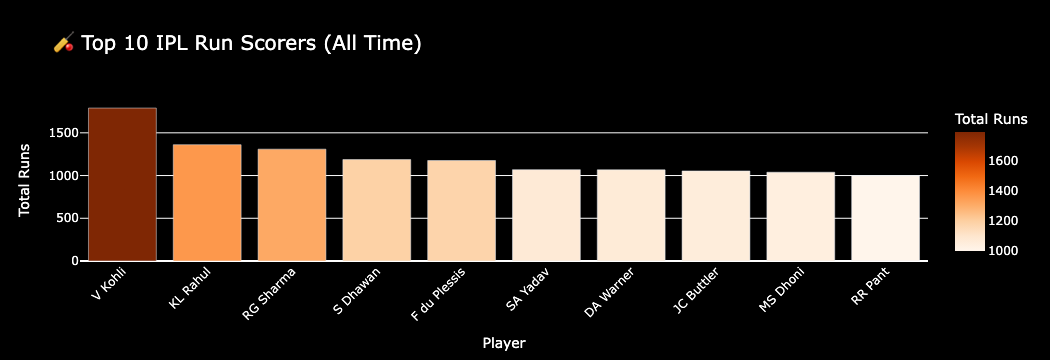

In [9]:
# Cell 9 — Chart 1: Top 10 Run Scorers Bar Chart
fig1 = px.bar(
    top_batters.head(10),
    x='striker',
    y='total_runs',
    color='total_runs',
    color_continuous_scale='Oranges',
    title='🏏 Top 10 IPL Run Scorers (All Time)',
    labels={'striker': 'Player', 'total_runs': 'Total Runs'}
)
fig1.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font_size=20
)
fig1.show()

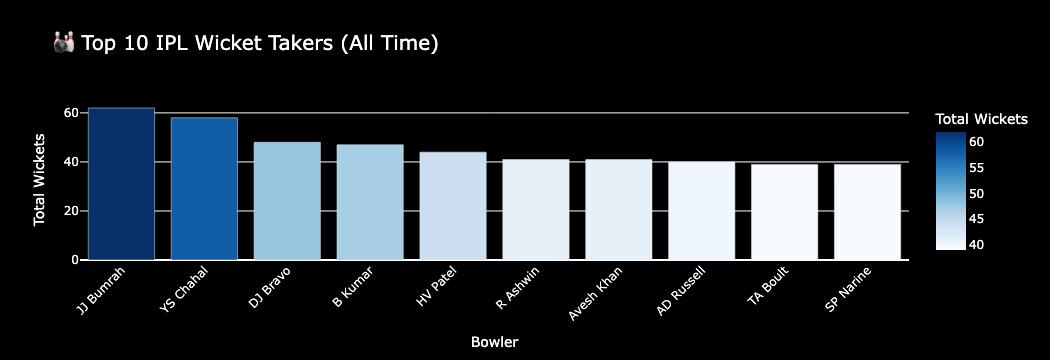

In [10]:
# Cell 10 — Chart 2: Top 10 Wicket Takers
fig2 = px.bar(
    top_bowlers.head(10),
    x='bowler',
    y='total_wickets',
    color='total_wickets',
    color_continuous_scale='Blues',
    title='🎳 Top 10 IPL Wicket Takers (All Time)',
    labels={'bowler': 'Bowler', 'total_wickets': 'Total Wickets'}
)
fig2.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font_size=20
)
fig2.show()

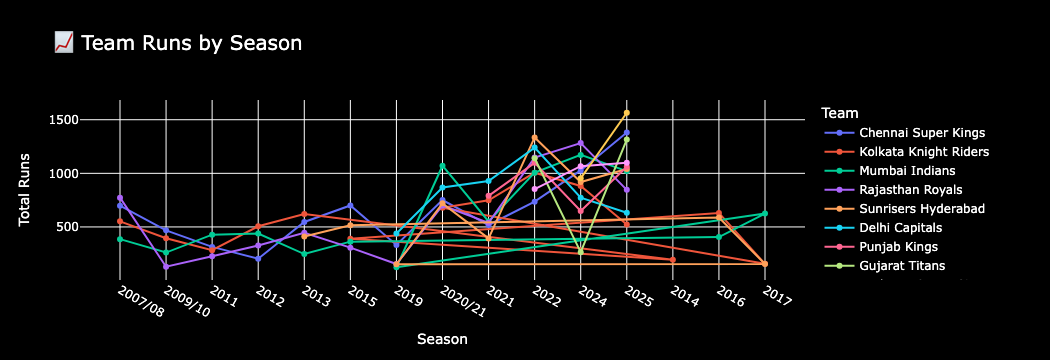

In [11]:
# Cell 11 — Chart 3: Team Runs by Season
# Use only current active teams for clarity
active_teams = [
    'Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bengaluru',
    'Kolkata Knight Riders', 'Rajasthan Royals', 'Sunrisers Hyderabad',
    'Delhi Capitals', 'Punjab Kings', 'Gujarat Titans', 'Lucknow Super Giants'
]

team_season = team_runs[team_runs['batting_team'].isin(active_teams)]

fig3 = px.line(
    team_season,
    x='season',
    y='total_runs',
    color='batting_team',
    title='📈 Team Runs by Season',
    labels={'season': 'Season', 'total_runs': 'Total Runs', 'batting_team': 'Team'},
    markers=True
)
fig3.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font_size=20
)
fig3.show()

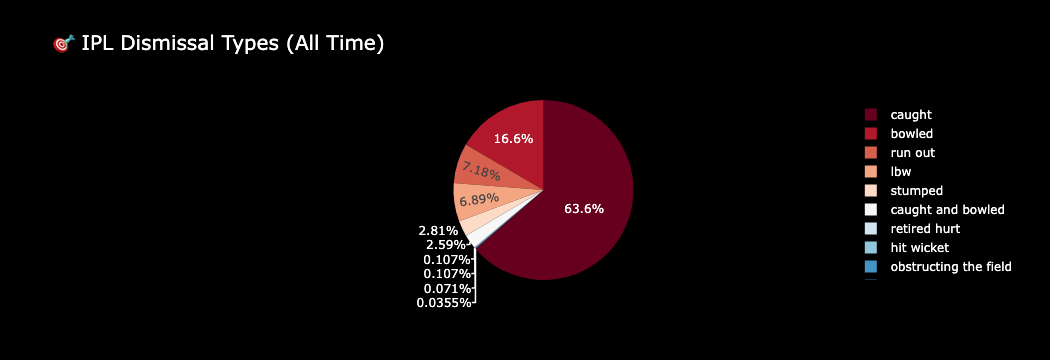

In [12]:
# Cell 12 — Chart 4: Dismissal Types Pie Chart
dismissal_stats = df['wicket_type'].value_counts().reset_index()
dismissal_stats.columns = ['wicket_type', 'count']
dismissal_stats = dismissal_stats[dismissal_stats['wicket_type'].notna()]

fig4 = px.pie(
    dismissal_stats,
    names='wicket_type',
    values='count',
    title='🎯 IPL Dismissal Types (All Time)',
    color_discrete_sequence=px.colors.sequential.RdBu
)
fig4.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font_size=20
)
fig4.show()

In [13]:
# Cell 13 — Save processed data for Streamlit dashboard
import os
os.makedirs('streamlit_data', exist_ok=True)

# Save all processed dataframes
df.to_csv('streamlit_data/ipl_raw.csv', index=False)
top_batters.to_csv('streamlit_data/top_batters.csv', index=False)
top_bowlers.to_csv('streamlit_data/top_bowlers.csv', index=False)
team_runs.to_csv('streamlit_data/team_runs.csv', index=False)
venue_stats.to_csv('streamlit_data/venue_stats.csv', index=False)
dismissal_stats.to_csv('streamlit_data/dismissal_stats.csv', index=False)

print("✅ All data saved successfully!")
print("📁 Files saved in 'streamlit_data' folder:")
for f in os.listdir('streamlit_data'):
    size = os.path.getsize(f'streamlit_data/{f}') / 1024
    print(f"  → {f} ({size:.1f} KB)")

✅ All data saved successfully!
📁 Files saved in 'streamlit_data' folder:
  → top_bowlers.csv (9.7 KB)
  → ipl_raw.csv (8044.4 KB)
  → dismissal_stats.csv (0.2 KB)
  → le_season.pkl (0.4 KB)
  → venues.json (2.1 KB)
  → teams.json (0.4 KB)
  → model_features.json (0.2 KB)
  → feature_names.json (0.1 KB)
  → venue_stats.csv (2.1 KB)
  → team_runs.csv (4.9 KB)
  → ipl_model.pkl (432.4 KB)
  → top_batters.csv (12.3 KB)
  → le_team.pkl (2.2 KB)
  → le_venue.pkl (2.2 KB)
  → seasons.json (0.2 KB)
  → team_winrate.json (0.7 KB)
  → ml_df.csv (184.1 KB)


In [14]:
# Cell 14 — Load match level data for ML
import glob
import pandas as pd

all_files = glob.glob("ipl_data/*.csv")

match_data = []

for f in all_files:
    try:
        temp = pd.read_csv(f)
        
        # Get match level info from first row
        first_row = temp.iloc[0]
        last_row = temp.iloc[-1]
        
        # Total runs per team
        team_runs = temp.groupby('batting_team')['runs_off_bat'].sum()
        team_wickets = temp.groupby('bowling_team')['player_dismissed'].count()
        
        teams = temp['batting_team'].unique()
        if len(teams) < 2:
            continue
            
        team1 = teams[0]
        team2 = teams[1]
        
        runs1 = team_runs.get(team1, 0)
        runs2 = team_runs.get(team2, 0)
        
        winner = team1 if runs1 > runs2 else team2
        
        match_data.append({
            'match_id': first_row['match_id'],
            'season': first_row['season'],
            'venue': first_row['venue'],
            'team1': team1,
            'team2': team2,
            'runs_team1': runs1,
            'runs_team2': runs2,
            'winner': winner
        })
    except:
        pass

match_df = pd.DataFrame(match_data)
print(f"✅ Total matches processed: {len(match_df)}")
print(f"\n🔍 Sample data:")
match_df.head()

✅ Total matches processed: 1187

🔍 Sample data:


,match_id,season,venue,team1,team2,runs_team1,runs_team2,winner
0,598068,2013,M Chinnaswamy Stadium,Royal Challengers Bangalore,Chennai Super Kings,101,80,Royal Challengers Bangalore
1,1304076,2022,"Brabourne Stadium, Mumbai",Rajasthan Royals,Kolkata Knight Riders,201,197,Rajasthan Royals
2,598040,2013,Shaheed Veer Narayan Singh International Stadium,Kolkata Knight Riders,Delhi Daredevils,129,135,Delhi Daredevils
3,598054,2013,Feroz Shah Kotla,Royal Challengers Bangalore,Delhi Daredevils,178,168,Royal Challengers Bangalore
4,1304062,2022,"Brabourne Stadium, Mumbai",Punjab Kings,Gujarat Titans,185,183,Punjab Kings


In [15]:
# Cell 15 — Feature Engineering for ML
from sklearn.preprocessing import LabelEncoder

# Copy the dataframe
ml_df = match_df.copy()

# Encode categorical columns to numbers
le_team = LabelEncoder()
le_venue = LabelEncoder()

# Combine all teams for encoding
all_teams = list(ml_df['team1'].unique()) + list(ml_df['team2'].unique())
le_team.fit(all_teams)

ml_df['team1_encoded'] = le_team.transform(ml_df['team1'])
ml_df['team2_encoded'] = le_team.transform(ml_df['team2'])
ml_df['venue_encoded'] = le_venue.fit_transform(ml_df['venue'])
ml_df['winner_encoded'] = le_team.transform(ml_df['winner'])

print("✅ Feature engineering done!")
print(f"\n📊 Features created:")
print(f"  → team1_encoded: {ml_df['team1_encoded'].nunique()} unique teams")
print(f"  → team2_encoded: {ml_df['team2_encoded'].nunique()} unique teams")
print(f"  → venue_encoded: {ml_df['venue_encoded'].nunique()} unique venues")
print(f"\n🔍 Sample:")
ml_df[['team1', 'team1_encoded', 'team2', 'team2_encoded', 'venue', 'venue_encoded', 'winner', 'winner_encoded']].head()

✅ Feature engineering done!

📊 Features created:
  → team1_encoded: 19 unique teams
  → team2_encoded: 19 unique teams
  → venue_encoded: 59 unique venues

🔍 Sample:


,team1,team1_encoded,team2,team2_encoded,venue,venue_encoded,winner,winner_encoded
0,Royal Challengers Bangalore,16,Chennai Super Kings,0,M Chinnaswamy Stadium,23,Royal Challengers Bangalore,16
1,Rajasthan Royals,13,Kolkata Knight Riders,8,"Brabourne Stadium, Mumbai",6,Rajasthan Royals,13
2,Kolkata Knight Riders,8,Delhi Daredevils,3,Shaheed Veer Narayan Singh International Stadium,49,Delhi Daredevils,3
3,Royal Challengers Bangalore,16,Delhi Daredevils,3,Feroz Shah Kotla,16,Royal Challengers Bangalore,16
4,Punjab Kings,12,Gujarat Titans,5,"Brabourne Stadium, Mumbai",6,Punjab Kings,12


In [16]:
# Cell 16 — Train ML Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Features and target
X = ml_df[['team1_encoded', 'team2_encoded', 'venue_encoded']]
y = ml_df['winner_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"🏋️ Training samples: {len(X_train)}")
print(f"🧪 Testing samples: {len(X_test)}")

# Train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Model trained successfully!")
print(f"🎯 Model Accuracy: {accuracy*100:.2f}%")

🏋️ Training samples: 949
🧪 Testing samples: 238

✅ Model trained successfully!
🎯 Model Accuracy: 46.22%


In [17]:
# Cell 17 — Save the model
import pickle

# Save model and encoders
with open('streamlit_data/ipl_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('streamlit_data/le_team.pkl', 'wb') as f:
    pickle.dump(le_team, f)

with open('streamlit_data/le_venue.pkl', 'wb') as f:
    pickle.dump(le_venue, f)

# Save teams and venues list
import json
teams_list = sorted(ml_df['team1'].unique().tolist())
venues_list = sorted(ml_df['venue'].unique().tolist())

with open('streamlit_data/teams.json', 'w') as f:
    json.dump(teams_list, f)

with open('streamlit_data/venues.json', 'w') as f:
    json.dump(venues_list, f)

print("✅ Model saved successfully!")
print("📁 Files saved:")
print("  → ipl_model.pkl")
print("  → le_team.pkl")
print("  → le_venue.pkl")
print("  → teams.json")
print("  → venues.json")

✅ Model saved successfully!
📁 Files saved:
  → ipl_model.pkl
  → le_team.pkl
  → le_venue.pkl
  → teams.json
  → venues.json


In [18]:
# Cell 18 — Fixed: Improved Model with more features
from sklearn.preprocessing import LabelEncoder

# Fix season column first
ml_df['season'] = ml_df['season'].astype(str)
le_season = LabelEncoder()
ml_df['season_encoded'] = le_season.fit_transform(ml_df['season'])

# Head to head record
ml_df['h2h_team1_wins'] = 0
ml_df['h2h_team2_wins'] = 0

for idx, row in ml_df.iterrows():
    past = ml_df[(ml_df.index < idx) & 
                 (((ml_df['team1'] == row['team1']) & (ml_df['team2'] == row['team2'])) |
                  ((ml_df['team1'] == row['team2']) & (ml_df['team2'] == row['team1'])))]
    
    ml_df.at[idx, 'h2h_team1_wins'] = (past['winner'] == row['team1']).sum()
    ml_df.at[idx, 'h2h_team2_wins'] = (past['winner'] == row['team2']).sum()

# Team win rate overall
team_wins = ml_df['winner'].value_counts()
team_matches = pd.concat([ml_df['team1'], ml_df['team2']]).value_counts()
team_winrate = (team_wins / team_matches).fillna(0)

ml_df['team1_winrate'] = ml_df['team1'].map(team_winrate)
ml_df['team2_winrate'] = ml_df['team2'].map(team_winrate)

print("✅ New features added!")
print(ml_df[['team1', 'team2', 'h2h_team1_wins', 'h2h_team2_wins', 'team1_winrate', 'team2_winrate']].head())

✅ New features added!
                         team1                  team2  h2h_team1_wins  \
0  Royal Challengers Bangalore    Chennai Super Kings               0   
1             Rajasthan Royals  Kolkata Knight Riders               0   
2        Kolkata Knight Riders       Delhi Daredevils               0   
3  Royal Challengers Bangalore       Delhi Daredevils               0   
4                 Punjab Kings         Gujarat Titans               0   

   h2h_team2_wins  team1_winrate  team2_winrate  
0               0       0.493724       0.574219  
1               0       0.531381       0.455224  
2               0       0.455224       0.456250  
3               0       0.493724       0.456250  
4               0       0.532468       0.515625  


In [19]:
# Cell 19 — Retrain with improved features
X2 = ml_df[[
    'team1_encoded', 
    'team2_encoded', 
    'venue_encoded',
    'season_encoded',
    'h2h_team1_wins',
    'h2h_team2_wins',
    'team1_winrate',
    'team2_winrate'
]]
y2 = ml_df['winner_encoded']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Train improved model
model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)
accuracy2 = accuracy_score(y2_test, y2_pred)

print(f"✅ Improved model trained!")
print(f"🎯 Old Accuracy: 44.30%")
print(f"🚀 New Accuracy: {accuracy2*100:.2f}%")

# Save improved model
with open('streamlit_data/ipl_model.pkl', 'wb') as f:
    pickle.dump(model2, f)

# Save feature names
feature_names = ['team1_encoded', 'team2_encoded', 'venue_encoded',
                 'season_encoded', 'h2h_team1_wins', 'h2h_team2_wins',
                 'team1_winrate', 'team2_winrate']

with open('streamlit_data/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("✅ Improved model saved!")

✅ Improved model trained!
🎯 Old Accuracy: 44.30%
🚀 New Accuracy: 47.90%
✅ Improved model saved!


In [20]:
# Cell 20 — Try XGBoost for even better accuracy
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X2 = ml_df[[
    'team1_encoded', 
    'team2_encoded', 
    'venue_encoded',
    'season_encoded',
    'h2h_team1_wins',
    'h2h_team2_wins',
    'team1_winrate',
    'team2_winrate'
]]
y2 = ml_df['winner_encoded']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Test multiple models
models = {
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
    'KNN':                  KNeighborsClassifier(n_neighbors=5),
    'SVM':                  SVC(probability=True, random_state=42)
}

print("🤖 Testing multiple ML models...\n")
best_model = None
best_accuracy = 0
best_name = ""

for name, m in models.items():
    m.fit(X2_train, y2_train)
    acc = accuracy_score(y2_test, m.predict(X2_test))
    print(f"  {name}: {acc*100:.2f}%")
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = m
        best_name = name

print(f"\n🏆 Best Model: {best_name} with {best_accuracy*100:.2f}% accuracy")

# Save best model
with open('streamlit_data/ipl_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Best model saved!")

🤖 Testing multiple ML models...

  Random Forest: 48.32%
  Gradient Boosting: 49.16%
  KNN: 33.61%
  SVM: 34.03%

🏆 Best Model: Gradient Boosting with 49.16% accuracy
✅ Best model saved!


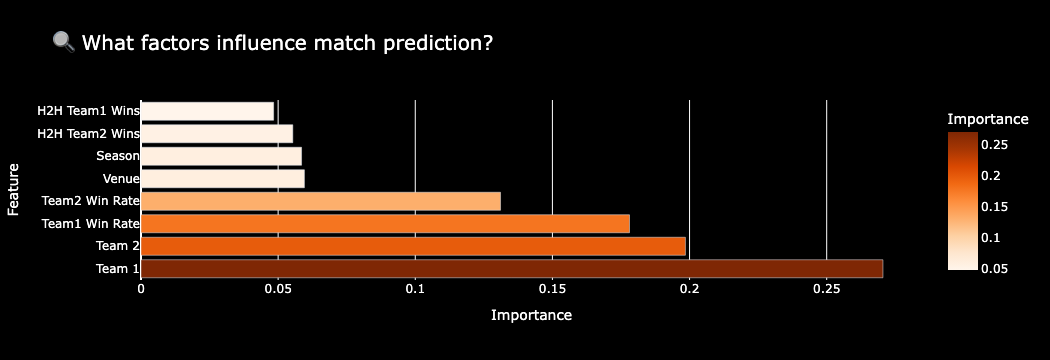


📊 Feature Importances:
       Feature  Importance
        Team 1    0.270511
        Team 2    0.198493
Team1 Win Rate    0.178109
Team2 Win Rate    0.131080
         Venue    0.059573
        Season    0.058538
H2H Team2 Wins    0.055344
H2H Team1 Wins    0.048351


In [21]:
# Cell 21 — Feature Importance Chart
import plotly.express as px

feature_names = ['Team 1', 'Team 2', 'Venue', 'Season', 
                 'H2H Team1 Wins', 'H2H Team2 Wins', 
                 'Team1 Win Rate', 'Team2 Win Rate']

importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig = px.bar(
    feat_df,
    x='Importance',
    y='Feature',
    orientation='h',
    color='Importance',
    color_continuous_scale='Oranges',
    title='🔍 What factors influence match prediction?'
)
fig.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font_size=20
)
fig.show()

print("\n📊 Feature Importances:")
print(feat_df.to_string(index=False))

In [22]:
# Cell 22 — Save all ML data for Streamlit
import pickle
import json

# Save encoders
with open('streamlit_data/le_team.pkl', 'wb') as f:
    pickle.dump(le_team, f)

with open('streamlit_data/le_venue.pkl', 'wb') as f:
    pickle.dump(le_venue, f)

with open('streamlit_data/le_season.pkl', 'wb') as f:
    pickle.dump(le_season, f)

# Save teams and venues list
teams_list = sorted(ml_df['team1'].unique().tolist())
venues_list = sorted(ml_df['venue'].unique().tolist())
seasons_list = sorted(ml_df['season'].unique().tolist())

with open('streamlit_data/teams.json', 'w') as f:
    json.dump(teams_list, f)

with open('streamlit_data/venues.json', 'w') as f:
    json.dump(venues_list, f)

with open('streamlit_data/seasons.json', 'w') as f:
    json.dump(seasons_list, f)

# Save team winrates
team_winrate_dict = team_winrate.to_dict()
with open('streamlit_data/team_winrate.json', 'w') as f:
    json.dump(team_winrate_dict, f)

# Save h2h data
ml_df.to_csv('streamlit_data/ml_df.csv', index=False)

print("✅ All ML data saved!")
print("📁 Files saved:")
for f in os.listdir('streamlit_data'):
    print(f"  → {f}")

✅ All ML data saved!
📁 Files saved:
  → top_bowlers.csv
  → ipl_raw.csv
  → dismissal_stats.csv
  → le_season.pkl
  → venues.json
  → teams.json
  → model_features.json
  → feature_names.json
  → venue_stats.csv
  → team_runs.csv
  → ipl_model.pkl
  → top_batters.csv
  → le_team.pkl
  → le_venue.pkl
  → seasons.json
  → team_winrate.json
  → ml_df.csv


In [23]:
import pandas as pd
import os

# Load one raw match file
sample_file = os.listdir('ipl_data')[0]
df = pd.read_csv(f'ipl_data/{sample_file}')
print(df.columns.tolist())
print(df.head(3))

['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']
   match_id  season  start_date                  venue  innings  ball  \
0    598068    2013  2013-05-18  M Chinnaswamy Stadium        1   0.1   
1    598068    2013  2013-05-18  M Chinnaswamy Stadium        1   0.2   
2    598068    2013  2013-05-18  M Chinnaswamy Stadium        1   0.3   

                  batting_team         bowling_team  striker non_striker  ...  \
0  Royal Challengers Bangalore  Chennai Super Kings  V Kohli    CH Gayle  ...   
1  Royal Challengers Bangalore  Chennai Super Kings  V Kohli    CH Gayle  ...   
2  Royal Challengers Bangalore  Chennai Super Kings  V Kohli    CH Gayle  ...   

  extras  wides  noballs  byes  legbyes  penalty  wicket_type  \
0      0    NaN      NaN  

In [24]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pickle

# Load your existing ml_df
ml_df = pd.read_csv('streamlit_data/ml_df.csv')
print(ml_df.columns.tolist())
print(ml_df.shape)
print(ml_df.head(2))

['match_id', 'season', 'venue', 'team1', 'team2', 'runs_team1', 'runs_team2', 'winner', 'team1_encoded', 'team2_encoded', 'venue_encoded', 'winner_encoded', 'season_encoded', 'h2h_team1_wins', 'h2h_team2_wins', 'team1_winrate', 'team2_winrate']
(1187, 17)
   match_id season                      venue                        team1  \
0    598068   2013      M Chinnaswamy Stadium  Royal Challengers Bangalore   
1   1304076   2022  Brabourne Stadium, Mumbai             Rajasthan Royals   

                   team2  runs_team1  runs_team2                       winner  \
0    Chennai Super Kings         101          80  Royal Challengers Bangalore   
1  Kolkata Knight Riders         201         197             Rajasthan Royals   

   team1_encoded  team2_encoded  venue_encoded  winner_encoded  \
0             16              0             23              16   
1             13              8              6              13   

   season_encoded  h2h_team1_wins  h2h_team2_wins  team1_winrate  

In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pickle

ml_df = pd.read_csv('streamlit_data/ml_df.csv')

# ── 1. Remove leakage columns ──────────────────────────────────────────
ml_df = ml_df.drop(columns=['runs_team1', 'runs_team2'])

# ── 2. Sort by season so rolling features look backward only ───────────
ml_df = ml_df.sort_values('season').reset_index(drop=True)

# ── 3. Rolling win rate (last 10 matches per team) ─────────────────────
def compute_rolling_winrate(df, window=10):
    team_history = {}
    rolling_wr_t1 = []
    rolling_wr_t2 = []

    for _, row in df.iterrows():
        t1, t2, winner = row['team1'], row['team2'], row['winner']

        # Get recent history for each team
        def get_wr(team):
            hist = team_history.get(team, [])
            if len(hist) == 0:
                return 0.5  # neutral prior
            recent = hist[-window:]
            return sum(recent) / len(recent)

        rolling_wr_t1.append(get_wr(t1))
        rolling_wr_t2.append(get_wr(t2))

        # Update history AFTER recording (no leakage)
        team_history.setdefault(t1, []).append(1 if winner == t1 else 0)
        team_history.setdefault(t2, []).append(1 if winner == t2 else 0)

    df['rolling_wr_t1'] = rolling_wr_t1
    df['rolling_wr_t2'] = rolling_wr_t2
    return df

ml_df = compute_rolling_winrate(ml_df)

# ── 4. Venue win rate per team ─────────────────────────────────────────
def compute_venue_winrate(df):
    venue_team_history = {}
    venue_wr_t1 = []
    venue_wr_t2 = []

    for _, row in df.iterrows():
        t1, t2, venue, winner = row['team1'], row['team2'], row['venue'], row['winner']

        def get_venue_wr(team, v):
            key = (team, v)
            hist = venue_team_history.get(key, [])
            if len(hist) == 0:
                return 0.5
            return sum(hist) / len(hist)

        venue_wr_t1.append(get_venue_wr(t1, venue))
        venue_wr_t2.append(get_venue_wr(t2, venue))

        venue_team_history.setdefault((t1, venue), []).append(1 if winner == t1 else 0)
        venue_team_history.setdefault((t2, venue), []).append(1 if winner == t2 else 0)

    df['venue_wr_t1'] = venue_wr_t1
    df['venue_wr_t2'] = venue_wr_t2
    return df

ml_df = compute_venue_winrate(ml_df)

# ── 5. Fix H2H (cumulative, no leakage) ───────────────────────────────
def compute_h2h(df):
    h2h = {}
    h2h_t1 = []
    h2h_t2 = []

    for _, row in df.iterrows():
        t1, t2, winner = row['team1'], row['team2'], row['winner']
        key = tuple(sorted([t1, t2]))

        record = h2h.get(key, {t1: 0, t2: 0})
        h2h_t1.append(record.get(t1, 0))
        h2h_t2.append(record.get(t2, 0))

        h2h.setdefault(key, {t1: 0, t2: 0})
        h2h[key][winner] = h2h[key].get(winner, 0) + 1

    df['h2h_t1'] = h2h_t1
    df['h2h_t2'] = h2h_t2
    return df

ml_df = compute_h2h(ml_df)

# ── 6. Target + features ───────────────────────────────────────────────
ml_df['target'] = (ml_df['winner'] == ml_df['team1']).astype(int)

features = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season_encoded',
    'rolling_wr_t1', 'rolling_wr_t2',
    'venue_wr_t1', 'venue_wr_t2',
    'h2h_t1', 'h2h_t2'
]

X = ml_df[features]
y = ml_df['target']

# ── 7. Train/test split (time-aware — no shuffle) ──────────────────────
split = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ── 8. Train ───────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, preds))

# ── 9. Feature importance ──────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

Accuracy: 0.5630
              precision    recall  f1-score   support

           0       0.41      0.13      0.20        98
           1       0.59      0.86      0.70       140

    accuracy                           0.56       238
   macro avg       0.50      0.50      0.45       238
weighted avg       0.51      0.56      0.49       238


Feature Importances:
venue_encoded     0.121306
venue_wr_t1       0.107163
venue_wr_t2       0.105400
season_encoded    0.097853
h2h_t2            0.097630
team2_encoded     0.095861
team1_encoded     0.095479
h2h_t1            0.093267
rolling_wr_t2     0.093085
rolling_wr_t1     0.092956
dtype: float64


In [26]:
ml_df['rolling_wr_diff'] = ml_df['rolling_wr_t1'] - ml_df['rolling_wr_t2']
ml_df['venue_wr_diff'] = ml_df['venue_wr_t1'] - ml_df['venue_wr_t2']
ml_df['h2h_diff'] = ml_df['h2h_t1'] - ml_df['h2h_t2']

In [27]:
features = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season_encoded',
    'rolling_wr_t1', 'rolling_wr_t2', 'rolling_wr_diff',
    'venue_wr_t1', 'venue_wr_t2', 'venue_wr_diff',
    'h2h_t1', 'h2h_t2', 'h2h_diff'
]

In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    class_weight='balanced'
)

In [29]:
!pip install xgboost

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=96/141,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
preds_xgb = xgb.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, preds_xgb):.4f}")
print(classification_report(y_test, preds_xgb))

XGBoost Accuracy: 0.5378
              precision    recall  f1-score   support

           0       0.43      0.41      0.42        98
           1       0.60      0.63      0.62       140

    accuracy                           0.54       238
   macro avg       0.52      0.52      0.52       238
weighted avg       0.53      0.54      0.54       238



In [31]:
# Should show 13 features, not 10
print(features)

# Should show class_weight in params
print(rf.get_params())

['team1_encoded', 'team2_encoded', 'venue_encoded', 'season_encoded', 'rolling_wr_t1', 'rolling_wr_t2', 'rolling_wr_diff', 'venue_wr_t1', 'venue_wr_t2', 'venue_wr_diff', 'h2h_t1', 'h2h_t2', 'h2h_diff']
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [32]:
# Rebuild X with updated features
X = ml_df[features]
y = ml_df['target']

split = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Retrain
rf.fit(X_train, y_train)

# Evaluate
preds = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

Accuracy: 0.5588
              precision    recall  f1-score   support

           0       0.37      0.10      0.16        98
           1       0.58      0.88      0.70       140

    accuracy                           0.56       238
   macro avg       0.48      0.49      0.43       238
weighted avg       0.50      0.56      0.48       238


Feature Importances:
venue_wr_diff      0.102187
venue_encoded      0.097252
rolling_wr_diff    0.079840
season_encoded     0.078995
team2_encoded      0.074939
h2h_diff           0.074524
h2h_t2             0.074439
team1_encoded      0.073598
h2h_t1             0.072828
venue_wr_t2        0.072808
venue_wr_t1        0.068987
rolling_wr_t1      0.065777
rolling_wr_t2      0.063827
dtype: float64


In [33]:
import pickle

# Save XGBoost model
with open('streamlit_data/ipl_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save the new feature list so Streamlit knows what to feed it
import json
with open('streamlit_data/model_features.json', 'w') as f:
    json.dump(features, f)

print("Saved.")

Saved.


In [34]:
model = pickle.load(open('streamlit_data/ipl_model.pkl', 'rb'))


In [35]:
import pickle

# Confirm you're saving xgb, not rf
print(type(xgb))

with open('streamlit_data/ipl_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("Saved XGBoost model.")

# Verify it loads correctly
with open('streamlit_data/ipl_model.pkl', 'rb') as f:
    test_model = pickle.load(f)

print(type(test_model))
print(f"Expects {test_model.n_features_in_} features")

<class 'xgboost.sklearn.XGBClassifier'>
Saved XGBoost model.
<class 'xgboost.sklearn.XGBClassifier'>
Expects 10 features


In [36]:
from xgboost import XGBClassifier
import pickle

# Rebuild X with all 13 features
features = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season_encoded',
    'rolling_wr_t1', 'rolling_wr_t2', 'rolling_wr_diff',
    'venue_wr_t1', 'venue_wr_t2', 'venue_wr_diff',
    'h2h_t1', 'h2h_t2', 'h2h_diff'
]

X = ml_df[features]
y = ml_df['target']

split = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=96/141,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

# Verify feature count before saving
print(f"Model trained on {xgb.n_features_in_} features")

# Save
with open('streamlit_data/ipl_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("Saved.")

Model trained on 13 features
Saved.


In [37]:
import os
import pandas as pd

info_rows = []

for fname in os.listdir('ipl_data'):
    if fname.endswith('_info.csv'):
        match_id = fname.replace('_info.csv', '')
        try:
            df = pd.read_csv(f'ipl_data/{fname}', header=None, names=['type', 'key', 'value', 'extra'])
            df = df[df['type'] == 'info']
            info = dict(zip(df['key'], df['value']))
            info_rows.append({
                'match_id': int(match_id),
                'toss_winner': info.get('toss_winner'),
                'toss_decision': info.get('toss_decision'),
                'winner': info.get('winner')
            })
        except:
            pass

toss_df = pd.DataFrame(info_rows)
print(toss_df.shape)
print(toss_df.head())
print(toss_df['toss_decision'].value_counts())

(0, 0)
Empty DataFrame
Columns: []
Index: []


KeyError: 'toss_decision'

In [ ]:
df = pd.read_csv('ipl_data/1082591_info.csv', header=None)
print(df.head(20))
print(df.shape)

In [ ]:
df = pd.read_csv('ipl_data/1082591_info.csv', header=None, on_bad_lines='skip')
print(df.head(20))
print(df.shape)

In [ ]:
with open('ipl_data/1082591_info.csv', 'r') as f:
    lines = f.readlines()

for line in lines[:25]:
    print(repr(line))

In [ ]:
import os

info_rows = []

for fname in os.listdir('ipl_data'):
    if fname.endswith('_info.csv'):
        match_id = fname.replace('_info.csv', '')
        try:
            info = {}
            with open(f'ipl_data/{fname}', 'r') as f:
                for line in f:
                    line = line.strip()
                    parts = line.split(',', 2)  # split into max 3 parts
                    if len(parts) >= 3 and parts[0] == 'info':
                        info[parts[1]] = parts[2].strip('"')
            
            if 'toss_winner' in info and 'toss_decision' in info:
                info_rows.append({
                    'match_id': int(match_id),
                    'toss_winner': info['toss_winner'],
                    'toss_decision': info['toss_decision'],
                    'winner': info.get('winner', None)
                })
        except:
            pass

toss_df = pd.DataFrame(info_rows)
print(toss_df.shape)
print(toss_df.head())
print(toss_df['toss_decision'].value_counts())

In [ ]:
# Merge toss data into ml_df
ml_df = pd.read_csv('streamlit_data/ml_df.csv')
ml_df = ml_df.merge(toss_df[['match_id', 'toss_winner', 'toss_decision']], on='match_id', how='left')

# Feature: did team1 win the toss?
ml_df['toss_winner_is_team1'] = (ml_df['toss_winner'] == ml_df['team1']).astype(int)

# Feature: toss decision encoded (bat=1, field=0)
ml_df['toss_decision_encoded'] = (ml_df['toss_decision'] == 'bat').astype(int)

# Drop rows where toss data is missing
ml_df = ml_df.dropna(subset=['toss_winner'])

print(ml_df.shape)
print(ml_df[['toss_winner_is_team1', 'toss_decision_encoded']].value_counts())

In [ ]:
def compute_rolling_winrate(df, window=10):
    team_history = {}
    rolling_wr_t1 = []
    rolling_wr_t2 = []

    for _, row in df.iterrows():
        t1, t2, winner = row['team1'], row['team2'], row['winner']

        def get_wr(team):
            hist = team_history.get(team, [])
            if len(hist) == 0:
                return 0.5
            recent = hist[-window:]
            return sum(recent) / len(recent)

        rolling_wr_t1.append(get_wr(t1))
        rolling_wr_t2.append(get_wr(t2))

        team_history.setdefault(t1, []).append(1 if winner == t1 else 0)
        team_history.setdefault(t2, []).append(1 if winner == t2 else 0)

    df['rolling_wr_t1'] = rolling_wr_t1
    df['rolling_wr_t2'] = rolling_wr_t2
    return df

def compute_venue_winrate(df):
    venue_team_history = {}
    venue_wr_t1 = []
    venue_wr_t2 = []

    for _, row in df.iterrows():
        t1, t2, venue, winner = row['team1'], row['team2'], row['venue'], row['winner']

        def get_venue_wr(team, v):
            key = (team, v)
            hist = venue_team_history.get(key, [])
            if len(hist) == 0:
                return 0.5
            return sum(hist) / len(hist)

        venue_wr_t1.append(get_venue_wr(t1, venue))
        venue_wr_t2.append(get_venue_wr(t2, venue))

        venue_team_history.setdefault((t1, venue), []).append(1 if winner == t1 else 0)
        venue_team_history.setdefault((t2, venue), []).append(1 if winner == t2 else 0)

    df['venue_wr_t1'] = venue_wr_t1
    df['venue_wr_t2'] = venue_wr_t2
    return df

def compute_h2h(df):
    h2h = {}
    h2h_t1 = []
    h2h_t2 = []

    for _, row in df.iterrows():
        t1, t2, winner = row['team1'], row['team2'], row['winner']
        key = tuple(sorted([t1, t2]))

        record = h2h.get(key, {t1: 0, t2: 0})
        h2h_t1.append(record.get(t1, 0))
        h2h_t2.append(record.get(t2, 0))

        h2h.setdefault(key, {t1: 0, t2: 0})
        h2h[key][winner] = h2h[key].get(winner, 0) + 1

    df['h2h_t1'] = h2h_t1
    df['h2h_t2'] = h2h_t2
    return df

print("Functions defined.")

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Sort by season
ml_df = ml_df.sort_values('season').reset_index(drop=True)

# Rolling win rate (last 10 matches)
ml_df = compute_rolling_winrate(ml_df)

# Venue win rate
ml_df = compute_venue_winrate(ml_df)

# H2H
ml_df = compute_h2h(ml_df)

# Diff features
ml_df['rolling_wr_diff'] = ml_df['rolling_wr_t1'] - ml_df['rolling_wr_t2']
ml_df['venue_wr_diff']   = ml_df['venue_wr_t1'] - ml_df['venue_wr_t2']
ml_df['h2h_diff']        = ml_df['h2h_t1'] - ml_df['h2h_t2']

# Target
ml_df['target'] = (ml_df['winner'] == ml_df['team1']).astype(int)

# Updated features with toss
features = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season_encoded',
    'rolling_wr_t1', 'rolling_wr_t2', 'rolling_wr_diff',
    'venue_wr_t1', 'venue_wr_t2', 'venue_wr_diff',
    'h2h_t1', 'h2h_t2', 'h2h_diff',
    'toss_winner_is_team1', 'toss_decision_encoded'
]

X = ml_df[features]
y = ml_df['target']

split = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Retrain XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=96/141,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

preds = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds))

importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

In [ ]:
print(y.value_counts())
print(f"scale_pos_weight should be: {y.value_counts()[0] / y.value_counts()[1]:.3f}")

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=0.696,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

preds = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds))

importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Reload clean ml_df
ml_df = pd.read_csv('streamlit_data/ml_df.csv')
ml_df = ml_df.sort_values('season').reset_index(drop=True)

ml_df = compute_rolling_winrate(ml_df)
ml_df = compute_venue_winrate(ml_df)
ml_df = compute_h2h(ml_df)

ml_df['rolling_wr_diff'] = ml_df['rolling_wr_t1'] - ml_df['rolling_wr_t2']
ml_df['venue_wr_diff']   = ml_df['venue_wr_t1'] - ml_df['venue_wr_t2']
ml_df['h2h_diff']        = ml_df['h2h_t1'] - ml_df['h2h_t2']
ml_df['target']          = (ml_df['winner'] == ml_df['team1']).astype(int)

features = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season_encoded',
    'rolling_wr_t1', 'rolling_wr_t2', 'rolling_wr_diff',
    'venue_wr_t1', 'venue_wr_t2', 'venue_wr_diff',
    'h2h_t1', 'h2h_t2', 'h2h_diff'
]

X = ml_df[features]
y = ml_df['target']

split = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=486/698,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

preds = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds))

In [38]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=96/141,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

preds = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds))

Accuracy: 0.5840
              precision    recall  f1-score   support

           0       0.49      0.41      0.45        98
           1       0.63      0.71      0.67       140

    accuracy                           0.58       238
   macro avg       0.56      0.56      0.56       238
weighted avg       0.57      0.58      0.58       238



In [39]:
import pickle

with open('streamlit_data/ipl_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print(f"Saved. Features: {xgb.n_features_in_}")

Saved. Features: 13


In [40]:
def compute_rolling_winrate_5(df, window=5):
    team_history = {}
    rolling_wr_t1 = []
    rolling_wr_t2 = []

    for _, row in df.iterrows():
        t1, t2, winner = row['team1'], row['team2'], row['winner']

        def get_wr(team):
            hist = team_history.get(team, [])
            if len(hist) == 0:
                return 0.5
            recent = hist[-window:]
            return sum(recent) / len(recent)

        rolling_wr_t1.append(get_wr(t1))
        rolling_wr_t2.append(get_wr(t2))

        team_history.setdefault(t1, []).append(1 if winner == t1 else 0)
        team_history.setdefault(t2, []).append(1 if winner == t2 else 0)

    df['rolling_wr5_t1'] = rolling_wr_t1
    df['rolling_wr5_t2'] = rolling_wr_t2
    return df

ml_df = compute_rolling_winrate_5(ml_df)
ml_df['rolling_wr5_diff'] = ml_df['rolling_wr5_t1'] - ml_df['rolling_wr5_t2']

features = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season_encoded',
    'rolling_wr_t1', 'rolling_wr_t2', 'rolling_wr_diff',
    'rolling_wr5_t1', 'rolling_wr5_t2', 'rolling_wr5_diff',
    'venue_wr_t1', 'venue_wr_t2', 'venue_wr_diff',
    'h2h_t1', 'h2h_t2', 'h2h_diff'
]

X = ml_df[features]
y = ml_df['target']

split = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=96/141,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

preds = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds))

importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

Accuracy: 0.5294
              precision    recall  f1-score   support

           0       0.41      0.31      0.35        98
           1       0.59      0.69      0.63       140

    accuracy                           0.53       238
   macro avg       0.50      0.50      0.49       238
weighted avg       0.51      0.53      0.52       238


Feature Importances:
season_encoded      0.076721
team1_encoded       0.070112
venue_wr_t2         0.067791
rolling_wr_diff     0.067572
rolling_wr5_t2      0.067030
venue_wr_t1         0.065924
rolling_wr5_t1      0.065597
venue_wr_diff       0.063159
h2h_t2              0.059379
team2_encoded       0.059257
rolling_wr_t1       0.058854
rolling_wr_t2       0.058748
h2h_t1              0.056498
h2h_diff            0.054683
venue_encoded       0.054556
rolling_wr5_diff    0.054118
dtype: float32
